# Garbage Classification based on text
### ENSF 617 - A2

Transfer learning with pretrained model [Distilbert](https://medium.com/huggingface/distilbert-8cf3380435b5)-base-uncased

Imports

In [1]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from transformers import AutoTokenizer, AutoModel
import os
import re
import numpy as np
import matplotlib.pyplot as plt

d:\conda_envs\torch_env\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Device Setup

In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cuda


Configurations

In [3]:
MODEL_NAME = "distilbert-base-uncased"
NUM_CLASSES = 4
BATCH_SIZE = 32
EPOCHS = 10
UNFREEZE_EPOCH = 5
INITIAL_LR = 1e-3
FINE_TUNE_LR = 2e-5
MAX_LEN = 128

DATA_ROOT = "E:\\pigeon\\Documents\\ENSF617A2\\garbage_data\\CVPR_2024_dataset_"
SAVE_PATH = "best_text_model.pth"

Load Tokenizer and Base Model

In [4]:
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
base_model = AutoModel.from_pretrained(MODEL_NAME).to(device)

Loading weights: 100%|██████████| 100/100 [00:00<00:00, 625.28it/s, Materializing param=transformer.layer.5.sa_layer_norm.weight]   
DistilBertModel LOAD REPORT from: distilbert-base-uncased
Key                     | Status     |  | 
------------------------+------------+--+-
vocab_layer_norm.weight | UNEXPECTED |  | 
vocab_transform.bias    | UNEXPECTED |  | 
vocab_transform.weight  | UNEXPECTED |  | 
vocab_layer_norm.bias   | UNEXPECTED |  | 
vocab_projector.bias    | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Read Text Data from given Folder 

Assuming your folder looks like this
```
root/
   Train/
      Blue/
      Green/
      ...
```

In [5]:
def read_text_files_with_labels(path):
    texts = []
    labels = []

    class_folders = sorted([
        f for f in os.listdir(path)
        if os.path.isdir(os.path.join(path, f)) and not f.startswith(".")
    ])

    label_map = {class_name: idx for idx, class_name in enumerate(class_folders)}

    # extract text from file names
    for class_name in class_folders:
        class_path = os.path.join(path, class_name)

        for file_name in sorted(os.listdir(class_path)):
            file_path = os.path.join(class_path, file_name)

            if os.path.isfile(file_path):
                text, _ = os.path.splitext(file_name)
                text = text.replace("_", " ")
                text = re.sub(r"\d+", "", text)

                texts.append(text)
                labels.append(label_map[class_name])

    return np.array(texts), np.array(labels)

Load Data

In [7]:
train_texts, train_labels = read_text_files_with_labels(DATA_ROOT + "Train")
val_texts, val_labels = read_text_files_with_labels(DATA_ROOT + "Val")
test_texts, test_labels = read_text_files_with_labels(DATA_ROOT + "Test")

Define Dataset Class

In [ ]:
class TextDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_len=MAX_LEN):
        self.texts = texts
        self.labels = labels
        self.tokenizer = tokenizer
        self.max_len = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        text = str(self.texts[idx])
        encoding = self.tokenizer(
            text,
            padding="max_length",
            truncation=True,
            max_length=self.max_len,
            return_tensors="pt"
        )

        return {
            "input_ids": encoding["input_ids"].squeeze(0),
            "attention_mask": encoding["attention_mask"].squeeze(0),
            "label": torch.tensor(self.labels[idx], dtype=torch.long),
            "text": text
        }

Data Loaders

In [9]:
train_ds = TextDataset(train_texts, train_labels, tokenizer)
val_ds   = TextDataset(val_texts, val_labels, tokenizer)
test_ds  = TextDataset(test_texts, test_labels, tokenizer)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(val_ds, batch_size=BATCH_SIZE)
test_loader  = DataLoader(test_ds, batch_size=BATCH_SIZE)

Text Classifier (Model Definition)

In [10]:
class TextClassifier(nn.Module):
    def __init__(self, num_classes, base_model):
        super().__init__()
        self.base_model = base_model
        hidden_size = base_model.config.hidden_size
        self.fc = nn.Linear(hidden_size, num_classes)

    def forward(self, input_ids, attention_mask):
        outputs = self.base_model(input_ids=input_ids,
                                  attention_mask=attention_mask)

        last_hidden = outputs.last_hidden_state
        mask_expanded = attention_mask.unsqueeze(-1).expand(last_hidden.size()).float()

        summed = torch.sum(last_hidden * mask_expanded, dim=1)
        summed_mask = torch.clamp(mask_expanded.sum(dim=1), min=1e-9)
        pooled = summed / summed_mask

        return self.fc(pooled)

Initialize Model

In [11]:
model = TextClassifier(NUM_CLASSES, base_model).to(device)

# Freeze backbone initially
for param in model.base_model.parameters():
    param.requires_grad = False

Optimizer and Loss

In [12]:
criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.AdamW(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=INITIAL_LR
)

Training Loop 

In [13]:
train_losses = []
val_losses = []
best_val_loss = float("inf")

for epoch in range(EPOCHS):

    if epoch == UNFREEZE_EPOCH:
        print("Unfreezing DistilBERT backbone...")
        for param in model.base_model.parameters():
            param.requires_grad = True

        optimizer = torch.optim.AdamW(
            filter(lambda p: p.requires_grad, model.parameters()),
            lr=FINE_TUNE_LR
        )

        train_loader = DataLoader(train_ds, batch_size=8, shuffle=True)

    # ---- Train ----
    model.train()
    running_loss = 0
    correct = 0
    total = 0

    for batch in train_loader:
        input_ids = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        labels = batch["label"].to(device)

        optimizer.zero_grad()
        outputs = model(input_ids, attention_mask)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        preds = outputs.argmax(dim=1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    train_loss = running_loss / len(train_loader)
    train_acc = correct / total

    # ---- Validation ----
    model.eval()
    val_loss_total = 0
    correct = 0
    total = 0

    with torch.no_grad():
        for batch in val_loader:
            input_ids = batch["input_ids"].to(device)
            attention_mask = batch["attention_mask"].to(device)
            labels = batch["label"].to(device)

            outputs = model(input_ids, attention_mask)
            loss = criterion(outputs, labels)

            val_loss_total += loss.item()
            preds = outputs.argmax(dim=1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)

    val_loss = val_loss_total / len(val_loader)
    val_acc = correct / total

    train_losses.append(train_loss)
    val_losses.append(val_loss)

    print(f"Epoch {epoch+1}/{EPOCHS}")
    print(f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f}")
    print(f"Val Loss:   {val_loss:.4f} | Val Acc:   {val_acc:.4f}")
    print("-" * 40)

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(model.state_dict(), SAVE_PATH)
        print("Saved best model.")

Epoch 1/10
Train Loss: 0.7770 | Train Acc: 0.7142
Val Loss:   0.5948 | Val Acc:   0.7950
----------------------------------------
Saved best model.
Epoch 2/10
Train Loss: 0.5791 | Train Acc: 0.7916
Val Loss:   0.5337 | Val Acc:   0.8133
----------------------------------------
Saved best model.
Epoch 3/10
Train Loss: 0.5372 | Train Acc: 0.8051
Val Loss:   0.5087 | Val Acc:   0.8239
----------------------------------------
Saved best model.
Epoch 4/10
Train Loss: 0.5084 | Train Acc: 0.8152
Val Loss:   0.4872 | Val Acc:   0.8211
----------------------------------------
Saved best model.
Epoch 5/10
Train Loss: 0.4915 | Train Acc: 0.8209
Val Loss:   0.4718 | Val Acc:   0.8311
----------------------------------------
Saved best model.
Unfreezing DistilBERT backbone...
Epoch 6/10
Train Loss: 0.4008 | Train Acc: 0.8562
Val Loss:   0.3348 | Val Acc:   0.8894
----------------------------------------
Saved best model.
Epoch 7/10
Train Loss: 0.2726 | Train Acc: 0.9013
Val Loss:   0.3381 | Val Acc

Testing

In [16]:
from sklearn.metrics import confusion_matrix, classification_report
import numpy as np

model.load_state_dict(torch.load(SAVE_PATH))
model.eval()

all_preds = []
all_labels = []

with torch.no_grad():
    for batch in test_loader:
        input_ids = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        labels = batch["label"].to(device)

        outputs = model(input_ids, attention_mask)
        preds = outputs.argmax(dim=1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

all_preds = np.array(all_preds)
all_labels = np.array(all_labels)

accuracy = (all_preds == all_labels).mean()
print(f"Test Accuracy: {accuracy:.4f}")

Test Accuracy: 0.8456


Confusion Matrix:
[[499 107  11  78]
 [ 53 987  22  24]
 [ 29  53 705  12]
 [ 54  75  12 711]]


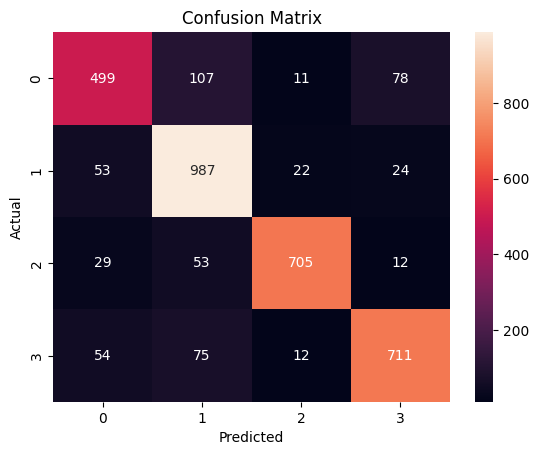

In [19]:
# Confusion Matrix
cm = confusion_matrix(all_labels, all_preds)
print("Confusion Matrix:")
print(cm)

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure()
sns.heatmap(cm, annot=True, fmt="d")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [20]:
# Classification Report
print("\nClassification Report:")
print(classification_report(all_labels, all_preds, digits=4))


Classification Report:
              precision    recall  f1-score   support

           0     0.7858    0.7180    0.7504       695
           1     0.8077    0.9088    0.8553      1086
           2     0.9400    0.8824    0.9103       799
           3     0.8618    0.8345    0.8479       852

    accuracy                         0.8456      3432
   macro avg     0.8488    0.8359    0.8410      3432
weighted avg     0.8475    0.8456    0.8450      3432

